In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Inclusion classification model training

Now it is time to train the models and assess their performance 

In [11]:
df_250_train  = pd.read_csv("Datasets/Train/250k_train.csv")
df_400t_train = pd.read_csv("Datasets/Train/400k_titles_infolep_train.csv")

df_250_test  = pd.read_csv("Datasets/Test/250k_test.csv")
df_400t_test = pd.read_csv("Datasets/Test/400k_titles_infolep_test.csv")

df_train_250k_split, df_val_250k_split = train_test_split(
    df_250_train,
    stratify=df_250_train['target'],
    test_size=0.1,
    random_state=42
)

df_train_400k_split, df_val_400k_split = train_test_split(
    df_400t_train,
    stratify=df_400t_train['target'],
    test_size=0.1,
    random_state=42
)

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16112\3836630059.py:2: DtypeWarning: Columns (36) have mixed types. Specify dtype option on import or set low_memory=False.
  df_400t_train = pd.read_csv("Datasets/Train/400k_titles_infolep_train.csv")


# ✅BERT

## Data preparation

In [15]:
from transformers import BertTokenizer, BertForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import torch
from scipy.special import softmax


In [3]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3070


### Test and val

In [12]:
#Let's use just relevant columns for speed. They can be joined later to analyse results. 
def combine_title_abstract(df):
    df = df.copy()
    df['text'] = df['title'].fillna('') + ' ' + df['abstract'].fillna('')
    return df[['row_id', 'text', 'target']]

df_train_bert = combine_title_abstract(df_train_250k_split)
df_val_bert   = combine_title_abstract(df_val_250k_split)
df_test_bert  = combine_title_abstract(df_250_test)
df_train_bert.head()

,row_id,text,target
217449,103874,[Antipsychotics in psychiatry.]. In this artic...,0
64293,175071,[Mucoadhesive buccal films of tramadol for eff...,0
126219,40690,The androgen receptor: a mediator of diverse r...,0
74345,157506,Randomized Trial of Group Music Therapy With C...,0
70379,138788,Reinforced Portland cement porous scaffolds fo...,0


### Checking the impact of truncating
Bert's token limit is just 512, which is quite short. Let's see how much of my data is longer than that.

In [17]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def get_lengths(texts):
    lengths = []
    for t in tqdm(texts):
        tokens = tokenizer(t, truncation=False, return_tensors="pt")
        lengths.append(tokens['input_ids'].shape[1])
    return lengths

# Combine title + abstract as before
texts = (df_250_train['title'].fillna('') + ' ' + df_250_train['abstract'].fillna('')).tolist()
lengths = get_lengths(texts)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

100%|██████████| 220243/220243 [15:07<00:00, 242.67it/s]


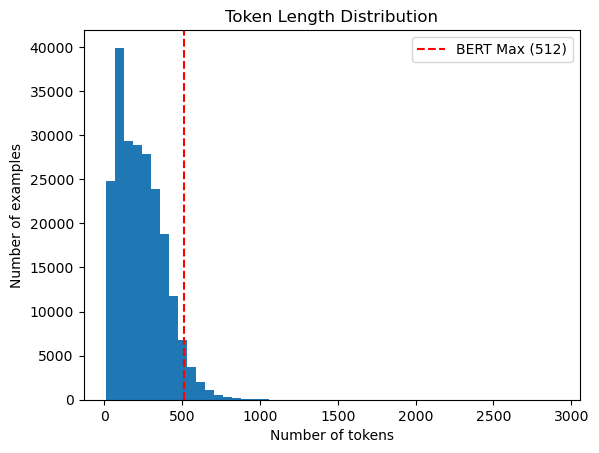

In [19]:
plt.hist(lengths, bins=50)
plt.title("Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Number of examples")
plt.axvline(512, color='red', linestyle='--', label='BERT Max (512)')
plt.legend()
plt.show()


In [20]:
import numpy as np
print("Token length percentiles:")
print("95% percentile:", np.percentile(lengths, 95))
print("99% percentile:", np.percentile(lengths, 99))


Token length percentiles:
95% percentile: 505.0
99% percentile: 664.0


In [27]:
def compute_truncation_stats(lengths, limit=512):
    lengths = np.array(lengths)
    over_limit = (lengths > limit).sum()
    total = len(lengths)
    percent_over = 100 * over_limit / total
    print(f"⚠️ {over_limit} out of {total} rows ({percent_over:.2f}%) exceed {limit} tokens.")
    return None

compute_truncation_stats(lengths, limit=700)
compute_truncation_stats(lengths, limit=600)
compute_truncation_stats(lengths, limit=512)
compute_truncation_stats(lengths, limit=384)
compute_truncation_stats(lengths, limit=256)


⚠️ 1560 out of 220243 rows (0.71%) exceed 700 tokens.
⚠️ 4107 out of 220243 rows (1.86%) exceed 600 tokens.
⚠️ 10107 out of 220243 rows (4.59%) exceed 512 tokens.
⚠️ 36597 out of 220243 rows (16.62%) exceed 384 tokens.
⚠️ 90751 out of 220243 rows (41.20%) exceed 256 tokens.


Only 4.59% of title-abstract pairs (10107) exceed the limit for BERT. It should be fine to just truncate it.

### Actual mapping / set making

In [13]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=512)

train_dataset = Dataset.from_pandas(df_train_bert)
val_dataset   = Dataset.from_pandas(df_val_bert)
test_dataset  = Dataset.from_pandas(df_test_bert)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized   = val_dataset.map(tokenize_function, batched=True)
test_tokenized  = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'target'])
val_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'target'])
test_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'target'])

Map:   0%|          | 0/198218 [00:00<?, ? examples/s]

Map:   0%|          | 0/22025 [00:00<?, ? examples/s]

Map:   0%|          | 0/55061 [00:00<?, ? examples/s]

In [20]:
# Patch: rename target → labels before formatting
train_tokenized = train_tokenized.rename_columns({'target': 'labels'})
val_tokenized   = val_tokenized.rename_columns({'target': 'labels'})
test_tokenized  = test_tokenized.rename_columns({'target': 'labels'})

# Then format for PyTorch
for dset in [train_tokenized, val_tokenized, test_tokenized]:
    dset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

## Training

In [23]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Using device:", torch.cuda.get_device_name(0))


CUDA available: True
Using device: NVIDIA GeForce RTX 3070


In [32]:
# 1. Load model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(torch.device("cuda"))

# 2. Define metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# 3. Name for this model/run
model_name = "bert_250k_title_abstract"

# 4. Training arguments
training_args = TrainingArguments(
    output_dir=f"./Eval_Results/{model_name}",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./Logs",
    logging_steps=50,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=1,
    report_to="none",
    fp16 = True
)

# 5. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16112\1037300906.py:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.005500,0.007656,0.998320,0.991013,0.998043,0.984081
2,0.000000,0.005997,0.998865,0.993966,0.994686,0.993247


TrainOutput(global_step=49556, training_loss=0.01116467870285363, metrics={'train_runtime': 8105.6985, 'train_samples_per_second': 48.908, 'train_steps_per_second': 6.114, 'total_flos': 1.0430669434269696e+17, 'train_loss': 0.01116467870285363, 'epoch': 2.0})

In [33]:
# Evaluate on validation set
eval_results = trainer.evaluate()
print("📊 Final validation results:", eval_results)

# Save evaluation metrics
os.makedirs("Eval_Results", exist_ok=True)
with open(f"Eval_Results/{model_name}_eval.json", "w") as f:
    json.dump(eval_results, f, indent=2)

# ─────────────────────────────────────────────
# Predict on test set
preds_output = trainer.predict(test_tokenized)
logits = preds_output.predictions
probabilities = softmax(logits, axis=1)[:, 1]

# ─────────────────────────────────────────────
# Save predictions
df_test_bert = df_test_bert.reset_index(drop=True)
df_preds = df_test_bert[['row_id']].copy()
df_preds['prob_1'] = probabilities
df_preds['pred_label'] = (probabilities >= 0.5).astype(int)

os.makedirs("Model_Predictions", exist_ok=True)
df_preds.to_csv(f"Model_Predictions/{model_name}_preds.csv", index=False)
print(f"✅ Predictions saved to Model_Predictions/{model_name}_preds.csv")

# ─────────────────────────────────────────────
# Save model and tokenizer
os.makedirs("Models", exist_ok=True)
model.save_pretrained(f"Models/{model_name}")
tokenizer.save_pretrained(f"Models/{model_name}")
print(f"✅ Model + tokenizer saved to Models/{model_name}")

📊 Final validation results: {'eval_loss': 0.00599718140438199, 'eval_accuracy': 0.9988649262202043, 'eval_f1': 0.9939657253198165, 'eval_precision': 0.9946859903381643, 'eval_recall': 0.9932465026531597, 'eval_runtime': 103.6034, 'eval_samples_per_second': 212.59, 'eval_steps_per_second': 26.582, 'epoch': 2.0}
✅ Predictions saved to Model_Predictions/bert_250k_title_abstract_preds.csv
✅ Model + tokenizer saved to Models/bert_250k_title_abstract


## Inspecting results
### Main set

In [38]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# ─────────────────────────────────────────────
# 1. Load and merge with full test set columns
df_preds = pd.read_csv('Model_Predictions/bert_250k_title_abstract_preds.csv')
df_test  = pd.read_csv('Datasets/Test/250k_test.csv')

# Merge and retain all columns from df_test
df_merged = df_preds.merge(df_test, on='row_id', how='left')

# ─────────────────────────────────────────────
# 2. Basic evaluation
y_true = df_merged['target']
y_pred = df_merged['pred_label']

print("📊 Classification Report:")
print(classification_report(y_true, y_pred, digits=3))

# ─────────────────────────────────────────────
# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("\n🧾 Confusion Matrix:")
print(cm_df)

# ────────────────────────

📊 Classification Report:
              precision    recall  f1-score   support

           0      0.999     0.999     0.999     49879
           1      0.992     0.993     0.993      5182

    accuracy                          0.999     55061
   macro avg      0.996     0.996     0.996     55061
weighted avg      0.999     0.999     0.999     55061


🧾 Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0        49839           40
Actual 1           35         5147


In [ ]:
df_merged[['prob_1','pred_label','target','title','abstract']]


,prob_1,pred_label,target,title,abstract
0,0.999984,1,1,Primary Motor Cortex Representation of Handgri...,<p><strong>BACKGROUND: </strong>Leprosy is an ...
1,0.000006,0,0,Population Dynamics of Rhizobium leguminosarum...,The influence of cell surface properties on at...
2,0.000009,0,0,Applicability of machine learning techniques i...,The evaluation of food intake is important in ...
3,0.000009,0,0,Sociodemographic correlates of physical activi...,This study was to compare the levels of physic...
4,0.000011,0,0,Compensatory Role of Inositol 5-Phosphatase IN...,Inositol phosphatases are important regulators...
...,...,...,...,...,...
55056,0.000006,0,0,Improving the management of disruptive behavio...,The objective of this work is to improve the m...
55057,0.000006,0,0,High-dose recombinant human bone morphogenetic...,The 'off-label' use of high-dose recombinant h...
55058,0.000007,0,0,Hypoxia-Targeted Drug Q6 Induces G2-M Arrest a...,In spite of the tremendous efforts dedicated t...
55059,0.000007,0,0,Adhesion Promotes Allergic Rhinitis CD4<sup>+<...,Neuroimmune communication plays an important r...


Those results are too good. This actually makes seanse - the diseases have quite specific keywords. Let's comapre with other approaches to see if all methods could just work so well

In [41]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# Load tokenizer and model
model_path = "Models/bert_250k_title_abstract"
tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Function for manual prediction
def predict_ntd_relevance(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
    inputs = {key: val.to(device) for key, val in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).squeeze()
        pred_label = torch.argmax(probs).item()
        prob_1 = probs[1].item()

    return {
        "prediction": pred_label,
        "probability_class_1": round(prob_1, 4),
        "probability_class_0": round(probs[0].item(), 4)
    }


In [74]:
example_text = '''Disease like Noma'''
result = predict_ntd_relevance(example_text)
print(result)

{'prediction': 1, 'probability_class_1': 0.9591, 'probability_class_0': 0.0409}


In [76]:
df_merged[df_merged['target']!=df_merged['pred_label']]

,row_id,prob_1,pred_label,pmid,title,abstract,authors,language,year,month,...,field_domain_access_target_id,Type2,Type3,Type4,Type6,Type7,Type8,Disease,Keywords,target_no_mesh_adjustment
668,53237,0.038358,0,12076639.0,"Pharmacological characterization of mikatoxin,...",Symptoms of envenomation by the New-Guinean sm...,S Nirthanan; R Gao; P Gopalakrishnakone; M C E...,eng,2003.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1948,25570,0.006050,0,4207611.0,Studies on heterologous immunity in schistosom...,Observations were made on the development of i...,M G Taylor; G S Nelson; M Smith; B J Andrews,eng,1974.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2225,228035,0.009277,0,34405444.0,Managing chromoblastomycosis with acitretin pl...,Chromoblastomycosis (CBM) is an infectious dis...,Walter Belda; Ana Thereza Stradioto Casolato; ...,eng,2024.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2444,215062,0.996399,1,33099993.0,Traditional and New Methods of Bone Age Assess...,Bone age is one of biological indicators of ma...,Monika Prokop-Piotrkowska; Kamila Marszałek-Dz...,eng,2022.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2874,21297,0.001478,0,2449637.0,Mast cell degranulating peptide and dendrotoxi...,Dendrotoxin and mast cell degranulating peptid...,C E Stansfeld; S J Marsh; D N Parcej; J O Doll...,eng,1988.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50451,67421,0.966851,1,15321360.0,Chagas' disease in an obstetrical patient.,We report a case of a parturient with document...,H B Martin; J Wills,eng,2005.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
51064,63210,0.923592,1,12973630.0,Serological follow-up of Trypanosoma cruzi inf...,In 1987 the University of Guadalajara performe...,F Trujillo-Contreras; M A Yerenas,eng,2005.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
51116,39348,0.373476,0,9988489.0,"Nocardia, nocardiosis and mycetoma.",The recent emergence of invasive infections du...,P Boiron; R Locci; M Goodfellow; S A Gumaa; K ...,eng,1999.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
51743,97238,0.882225,1,17040714.0,Why don't we have a schistosomiasis vaccine?,Over the past 30 years there has been a concer...,R A Wilson; P S Coulson,eng,2011.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


### Just titles dataset
Let's look at the larger dataset with just titles. Does the model still perform so well, or worse?

In [77]:
# ────────────────────────────────
# Load model and tokenizer
model_path = "Models/bert_250k_title_abstract"
tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# ────────────────────────────────
# Load title-only test data
df_titles = pd.read_csv("Datasets/Test/400k_titles_test.csv")
texts = df_titles["title"].fillna("").tolist()
row_ids = df_titles["row_id"].tolist()

# ────────────────────────────────
# Run predictions in batches
batch_size = 32
pred_labels = []
pred_probs = []

for i in tqdm(range(0, len(texts), batch_size), desc="Predicting"):
    batch_texts = texts[i:i+batch_size]
    inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)

    preds = torch.argmax(probs, dim=1).tolist()
    prob_1 = probs[:, 1].tolist()

    pred_labels.extend(preds)
    pred_probs.extend(prob_1)

# ────────────────────────────────
# Assemble and save predictions
df_preds = pd.DataFrame({
    "row_id": row_ids,
    "pred_label": pred_labels,
    "prob_1": pred_probs
})

output_path = "Model_Predictions/bert_250k_on_400k_titles.csv"
df_preds.to_csv(output_path, index=False)
print(f"✅ Predictions saved to: {output_path}")

Predicting: 100%|██████████| 2764/2764 [02:06<00:00, 21.87it/s]


✅ Predictions saved to: Model_Predictions/bert_250k_on_400k_titles.csv


In [79]:
# ───────────────────────────────────────
# Load your prediction file and test set
df_preds = pd.read_csv("Model_Predictions/bert_250k_on_400k_titles.csv")
df_test  = pd.read_csv("Datasets/Test/400k_titles_test.csv")

# ───────────────────────────────────────
# Merge on row_id to retain full test info
df_merged = df_preds.merge(df_test, on="row_id", how="left")

# ───────────────────────────────────────
# Compute metrics
y_true = df_merged["target"]
y_pred = df_merged["pred_label"]

print("📊 Classification Report:\n")
print(classification_report(y_true, y_pred, digits=3))

print("\n🧾 Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
print(pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))

# ───────────────────────────────────────
# Optional: Save merged predictions
df_merged.to_csv("Eval_Results/bert_250k_on_400k_titles_full_merged.csv", index=False)

📊 Classification Report:

              precision    recall  f1-score   support

           0      0.973     0.998     0.985     79794
           1      0.980     0.740     0.843      8631

    accuracy                          0.973     88425
   macro avg      0.976     0.869     0.914     88425
weighted avg      0.973     0.973     0.971     88425


🧾 Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0        79666          128
Actual 1         2244         6387


Using just the titles the results are worse, but still impressive considering that the model was fine-tuned on longer text!

# ✅Gemini zero-shot

Let's see if this approach is better than zero-shot learning with Gemini. The reasoning for this is as follows - the fine-tuned is not easily adjustable to the user needs, it needs to be trained. But Gemini is just a prompt that can be altered by the user easily.

Let's first try to estimate the price of this experiment. I will estimate the Gemini tokens with another tokenizer

Post fact commentary: the total API cost for this was 1.60 EUR.

In [2]:
import os
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from google import genai
from google.genai import types
from sklearn.metrics import classification_report, confusion_matrix

In [1]:
import pandas as pd
from transformers import GPT2TokenizerFast

# Load test data
df = pd.read_csv("Datasets/Test/250k_test.csv")
df["text"] = df["title"].fillna('') + " " + df["abstract"].fillna('')

# Load tokenizer (approximate Gemini with GPT-2 tokenizer)
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")

# Count tokens
token_counts = df["text"].apply(lambda x: len(tokenizer.encode(x)))
print(f"🔢 Total tokens: {token_counts.sum():,}")
print(f"🟰 Average tokens per input: {token_counts.mean():.2f}")

Token indices sequence length is longer than the specified maximum sequence length for this model (1659 > 1024). Running this sequence through the model will result in indexing errors


🔢 Total tokens: 12,594,390
🟰 Average tokens per input: 228.74


## Querying

Ok this should be sub 2 dollars, so very achievable.

In [2]:
# ─── 1. API Key & Client ──────────────────────────────
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

# ─── 2. Load dataset ──────────────────────────────────
df = pd.read_csv("Datasets/Test/250k_test.csv")
df["text"] = df["title"].fillna('') + " " + df["abstract"].fillna('')

# ─── 3. Model & Inference Config ──────────────────────
model_name = "gemini-2.5-flash-preview-05-20"
config = types.GenerateContentConfig(
    thinking_config=types.ThinkingConfig(thinking_budget=0)
)

# ─── 4. Prompt Template ───────────────────────────────
def build_prompt(text):
    return (
        "You are an expert in tropical diseases."
        "Given the following medical research paper's title and abstract, answer only with 'Yes' or 'No':\n\n"
        f"{text}\n\n"
        "Is this paper about neglected tropical diseases?"
    )

# ─── 5. Manual Test Prompt ────────────────────────────
def test_single_prompt():
    test_text = input("📄 Enter a title + abstract to test Gemini: ")
    prompt = build_prompt(test_text)
    response = client.models.generate_content(
        model=model_name,
        contents=prompt,
        config=config
    )
    print("🔮 Gemini response:", response.text.strip())


# ─── 6. Batch Inference + Save ────────────────────────
def run_batch_prediction(df, output_path):
    predictions = []
    raw_responses = []

    for text in tqdm(df["text"], desc="Querying Gemini"):
        try:
            prompt = build_prompt(text)
            response = client.models.generate_content(
                model=model_name,
                contents=prompt,
                config=config
            )
            answer = response.text.strip()
            label = 1 if "yes" in answer.lower() else 0
        except Exception as e:
            answer = f"ERROR: {str(e)}"
            label = -1  # Mark failure

        predictions.append(label)
        raw_responses.append(answer)

    # Save with row_id, prediction, and raw response
    df_out = df[["row_id"]].copy()
    df_out["gemini_pred"] = predictions
    df_out["gemini_response"] = raw_responses

    df_out.to_csv(output_path, index=False)
    print(f"✅ Saved predictions to: {output_path}")

In [13]:
test_single_prompt()

🔮 Gemini response: Yes


Tested it works, let's run the whole set.

In [14]:
df = pd.read_csv("Datasets/Test/250k_test.csv")
df["text"] = df["title"].fillna('') + " " + df["abstract"].fillna('')

run_batch_prediction(df, "Model_Predictions/gemini_2-5_flash_250k_title_abstract_preds.csv")

Querying Gemini:   0%|          | 32/55061 [00:09<4:27:33,  3.43it/s]


KeyboardInterrupt: 

This is too slow, let's try paralell

In [11]:
import time

client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

# ─── Config ────────────────────────────────────────────
model_name = "gemini-2.0-flash"
# config = types.GenerateContentConfig(
#    # thinking_config=types.ThinkingConfig(thinking_budget=0)
# )

# ─── Prompt ────────────────────────────────────────────
def build_prompt(text):
    return (
        "You are an expert in tropical diseases. "
        "Given the following medical research paper's title and abstract, answer only with 'Yes' or 'No':\n\n"
        f"{text}\n\n"
        "Is this paper about neglected tropical diseases?"
    )

# ─── Cost Estimation ──────────────────────────────────
def estimate_cost(prompt_tokens, response_tokens):
    return round((prompt_tokens * 0.00025 + response_tokens * 0.00050) / 1000, 6)

# ─── Per-row Prediction ───────────────────────────────
def predict_one(row):
    row_id = row["row_id"]
    text = row["text"]
    prompt = build_prompt(text)

    try:
        response = client.models.generate_content(
            model=model_name,
            contents=prompt,
            # config=config
        )
        resp_text = response.text.strip()
        label = 1 if "yes" in resp_text.lower() else 0

        # Token info
        usage = response.usage_metadata
        prompt_tokens = usage.prompt_token_count or 0
        response_tokens = usage.candidates_token_count or 0
        total_tokens = usage.total_token_count or 0
        cost = estimate_cost(prompt_tokens, response_tokens)

    except Exception as e:
        label = -1
        resp_text = str(e)
        prompt_tokens = response_tokens = total_tokens = 0
        cost = 0.0

    return {
        "row_id": row_id,
        "gemini_pred": label,
        "gemini_response": resp_text,
        "prompt_tokens": prompt_tokens,
        "response_tokens": response_tokens,
        "total_tokens": total_tokens,
        "estimated_cost_usd": cost,
    }

# ─── Batch Prediction ─────────────────────────────────
def run_parallel_prediction(df, output_path, max_workers=1, throttle=True):
    results = []
    delay_between_requests = 60 / 1500 if throttle else 0  # ~0.04s per request

    if max_workers == 1:
        # ── Sequential mode with working tqdm ──
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Querying Gemini"):
            result = predict_one(row)
            results.append(result)
            if throttle:
                time.sleep(delay_between_requests)

    else:
        # ── Parallel mode ──
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = {executor.submit(predict_one, row): row for _, row in df.iterrows()}
            for future in tqdm(as_completed(futures), total=len(futures), desc="Querying Gemini"):
                results.append(future.result())

    df_out = pd.DataFrame(results)
    df_out.to_csv(output_path, index=False)
    print(f"\n✅ Saved predictions to: {output_path}")
    print(f"💰 Total estimated cost: ${df_out['estimated_cost_usd'].sum():.4f}")

In [17]:
df = pd.read_csv("Datasets/Test/250k_test.csv")
df["text"] = df["title"].fillna('') + " " + df["abstract"].fillna('')
run_parallel_prediction(df, "Model_Predictions/gemini_2-0_flash_250k_title_abstract_preds.csv", max_workers=1)

Querying Gemini: 100%|██████████| 55061/55061 [5:17:31<00:00,  2.89it/s]   



✅ Saved predictions to: Model_Predictions/gemini_2-0_flash_250k_title_abstract_preds.csv
💰 Total estimated cost: $3.5815


## Result inspection

In [19]:
# ───────────────────────────────────────
# Load your prediction file and test set
df_preds = pd.read_csv("Model_Predictions/gemini_2-0_flash_250k_title_abstract_preds.csv")
df_test  = pd.read_csv("Datasets/Test/250k_test.csv")

# ───────────────────────────────────────
# Merge on row_id to retain full test info
df_merged = df_preds.merge(df_test, on="row_id", how="left")

# ───────────────────────────────────────
# Filter out failed predictions (-1)
df_eval = df_merged[df_merged["gemini_pred"] != -1].copy()

# ───────────────────────────────────────
# Compute metrics
from sklearn.metrics import classification_report, confusion_matrix

y_true = df_eval["target"]
y_pred = df_eval["gemini_pred"]

print("📊 Classification Report:\n")
print(classification_report(y_true, y_pred, digits=3))

print("\n🧾 Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
print(pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))

# ───────────────────────────────────────
# Optional: Save merged predictions
df_eval.to_csv("Eval_Results/gemini_2-5_flash_250k_title_abstract_full_merged.csv", index=False)


📊 Classification Report:

              precision    recall  f1-score   support

           0      0.981     0.992     0.987     49872
           1      0.918     0.820     0.866      5181

    accuracy                          0.976     55053
   macro avg      0.950     0.906     0.926     55053
weighted avg      0.975     0.976     0.976     55053


🧾 Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0        49491          381
Actual 1          934         4247


In [15]:
df_preds

,row_id,gemini_pred,gemini_response,prompt_tokens,response_tokens,total_tokens,estimated_cost_usd
0,261184,1,Yes,513,2,515,0.000129
1,85587,0,No,428,2,430,0.000108
2,226952,0,No,282,2,284,0.000072
3,178930,0,No,559,2,561,0.000141
4,141983,0,No,354,2,356,0.000089


# ✅SVMs
## Data

In [23]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
import joblib

In [29]:
df_train = pd.read_csv("Datasets/Train/250k_train.csv")
df_test = pd.read_csv("Datasets/Test/250k_test.csv")

df_train["text"] = df_train["title"].fillna("") + " " + df_train["abstract"].fillna("")
df_test["text"] = df_test["title"].fillna("") + " " + df_test["abstract"].fillna("")

X_train = df_train["text"]
y_train = df_train["target"]

X_test = df_test["text"]
y_test = df_test["target"]

In [30]:
vectorizer = TfidfVectorizer(
    max_features=100_000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## Linear
### 250k

In [31]:
param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

base_model = LinearSVC(class_weight='balanced', max_iter=5000)

grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_tfidf, y_train)
best_base_model = grid.best_estimator_
print(f"✅ Best C: {grid.best_params_['C']}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
✅ Best C: 1


In [33]:
calibrated_model = CalibratedClassifierCV(estimator=best_base_model, cv=5)
calibrated_model.fit(X_train_tfidf, y_train)


probs = calibrated_model.predict_proba(X_test_tfidf)[:, 1]
preds = (probs >= 0.5).astype(int)

print("📊 Classification Report:\n")
print(classification_report(y_test, preds, digits=3))

print("\n🧾 Confusion Matrix:")
cm = confusion_matrix(y_test, preds)
print(pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))


df_out = df_test[["row_id"]].copy()
df_out["svm_pred_label"] = preds
df_out["svm_pred_prob"] = probs
df_out.to_csv("Model_Predictions/svm_250k_title_abstract_preds.csv", index=False)
print("✅ Saved predictions to 'Model_Predictions/svm_250k_title_abstract_preds.csv'")


os.makedirs("Models", exist_ok=True)
joblib.dump((vectorizer, calibrated_model), "Models/svm_250k_title_abstract.joblib")
print("💾 Model saved to 'Models/svm_250k_title_abstract.joblib'")

📊 Classification Report:

              precision    recall  f1-score   support

           0      0.995     0.997     0.996     49879
           1      0.971     0.953     0.962      5182

    accuracy                          0.993     55061
   macro avg      0.983     0.975     0.979     55061
weighted avg      0.993     0.993     0.993     55061


🧾 Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0        49733          146
Actual 1          245         4937
✅ Saved predictions to 'Model_Predictions/svm_250k_title_abstract_preds.csv'
💾 Model saved to 'Models/svm_250k_title_abstract.joblib'


### Same on 400k

In [36]:
model_path = "Models/svm_250k_title_abstract.joblib"
vectorizer, svm_model = joblib.load(model_path)

df_test = pd.read_csv("Datasets/Test/400k_titles_test.csv")

# Create 'text' column from just titles
df_test["text"] = df_test["title"].fillna("")

# Transform with the same TF-IDF vectorizer used during training
X_test_tfidf = vectorizer.transform(df_test["text"])

# ─── Make Predictions ─────────────────────────────────────────────────
probs = svm_model.predict_proba(X_test_tfidf)[:, 1]
y_pred = (probs >= 0.5).astype(int)  # Default threshold of 0.5

# ─── Evaluate Performance ─────────────────────────────────────────────
y_true = df_test["target"]

print("📊 Classification Report:")
print(classification_report(y_true, y_pred, digits=3))

print("\n🧾 Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
print(pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))

# ─── Save Results ─────────────────────────────────────────────────────
df_out = df_test.copy()
df_out["svm_pred"] = y_pred
df_out["svm_prob"] = probs

output_path = "Eval_Results/svm_250k_on_400k_titles_full_merged.csv"
df_out.to_csv(output_path, index=False)
print(f"\n✅ Predictions saved to: {output_path}")

📊 Classification Report:
              precision    recall  f1-score   support

           0      0.976     0.998     0.987     79794
           1      0.981     0.770     0.863      8631

    accuracy                          0.976     88425
   macro avg      0.978     0.884     0.925     88425
weighted avg      0.976     0.976     0.975     88425


🧾 Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0        79667          127
Actual 1         1984         6647

✅ Predictions saved to: Eval_Results/svm_250k_on_400k_titles_full_merged.csv


## Kernel

In [39]:
import os
import pandas as pd
import joblib
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

In [40]:
df_train = pd.read_csv("Datasets/Train/250k_train.csv")
df_test  = pd.read_csv("Datasets/Test/250k_test.csv")

df_train["text"] = df_train["title"].fillna("") + " " + df_train["abstract"].fillna("")
df_test["text"]  = df_test["title"].fillna("") + " " + df_test["abstract"].fillna("")

X_train = df_train["text"]
y_train = df_train["target"]

X_test = df_test["text"]
y_test = df_test["target"]

In [53]:
vectorizer = TfidfVectorizer(
    max_features=100_000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

In [55]:
param_grid = {
    "C": [1],
    "gamma": [0.001]
}

base_model = SVC(kernel='rbf', probability=False)

grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_tfidf, y_train)
best_base_model = grid.best_estimator_
print(f"✅ Best Params: {grid.best_params_}")


Fitting 3 folds for each of 1 candidates, totalling 3 fits


KeyboardInterrupt: 

In [ ]:
calibrated_model = CalibratedClassifierCV(estimator=best_base_model, cv=5)
calibrated_model.fit(X_train_tfidf, y_train)

probs = calibrated_model.predict_proba(X_test_tfidf)[:, 1]
preds = (probs >= 0.5).astype(int)

print("📊 Classification Report:\n")
print(classification_report(y_test, preds, digits=3))

print("\n🧾 Confusion Matrix:")
cm = confusion_matrix(y_test, preds)
print(pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))


df_out = df_test[["row_id"]].copy()
df_out["svm_rbf_pred_label"] = preds
df_out["svm_rbf_pred_prob"] = probs
df_out.to_csv("Model_Predictions/svm_rbf_250k_title_abstract_preds.csv", index=False)
print("✅ Saved predictions to 'Model_Predictions/svm_rbf_250k_title_abstract_preds.csv'")


os.makedirs("Models", exist_ok=True)
joblib.dump((vectorizer, calibrated_model), "Models/svm_rbf_250k_title_abstract.joblib")
print("💾 Model saved to 'Models/svm_rbf_250k_title_abstract.joblib'")

# Disease classification model training

## ✅SVM - only infoNTD
### Training

In [56]:
import os, joblib, pandas as pd, numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score

In [64]:
# 1. Load train / test  (infoNTD split)
# ─────────────────────────────────────────────────────────────
train_path = "Datasets/Disease_Classification/Train/infoNTD_train.csv"
test_path  = "Datasets/Disease_Classification/Test/infoNTD_test.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

# detect disease columns (binary 0/1)
disease_cols = [c for c in df_train.columns
                if set(df_train[c].dropna().unique()).issubset({0,1})
                and c not in ["row_id","Type7",'pmid','publication_type','month','mesh_terms','matched_diseases','lanugauge','country','authors','agency','language']]

In [66]:
len(disease_cols)

19

In [68]:
# 2. Build text field  (title + abstract)
# ─────────────────────────────────────────────────────────────
def make_text(df):
    return (
        df["title"].fillna("") + " " +
        df["abstract"].fillna("")
    ).str.strip()

X_train_text = make_text(df_train)
X_test_text  = make_text(df_test)

y_train = df_train[disease_cols].values
y_test  = df_test[disease_cols].values  # for evaluation only

# 3. TF-IDF Vectorizer
# ─────────────────────────────────────────────────────────────
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    sublinear_tf=True,
    max_features=100_000
)

X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

In [72]:
# 4. One-vs-Rest Linear SVM  with probability calibration
# ─────────────────────────────────────────────────────────────
base_svc = LinearSVC(class_weight="balanced", max_iter=5000)
ovr_svc  = OneVsRestClassifier(base_svc, n_jobs=-1)

param_grid = {"estimator__C": [0.01, 0.1, 1, 10]}
grid = GridSearchCV(
    estimator=ovr_svc,
    param_grid=param_grid,
    scoring="f1_micro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

print("🔧  Grid-searching C for LinearSVC …")
grid.fit(X_train, y_train)        # y_train = multi-hot labels
best_C = grid.best_params_["estimator__C"]
print("✅  Best C =", best_C)

🔧  Grid-searching C for LinearSVC …
Fitting 3 folds for each of 4 candidates, totalling 12 fits
✅  Best C = 1


### Eval

In [74]:
# -------------------------------------------------------------------
# 5 ▶ rebuild calibrated OvR SVM with that C
# -------------------------------------------------------------------
from sklearn.calibration import CalibratedClassifierCV

best_base = LinearSVC(C=best_C, class_weight="balanced", max_iter=5000)
cal_bin   = CalibratedClassifierCV(best_base, method="sigmoid", cv=3)
ovr_cal   = OneVsRestClassifier(cal_bin, n_jobs=-1)

print("📈  Training calibrated One-vs-Rest SVM …")
ovr_cal.fit(X_train, y_train)

# -------------------------------------------------------------------
# 6 ▶ evaluation on test
# -------------------------------------------------------------------
from sklearn.metrics import f1_score, classification_report

y_pred = ovr_cal.predict(X_test)
y_prob = ovr_cal.predict_proba(X_test)

print("\nMicro-F1 :", f1_score(y_test, y_pred, average="micro"))
print("Macro-F1 :", f1_score(y_test, y_pred, average="macro"))
print("\nPer-disease report:\n",
      classification_report(y_test, y_pred, target_names=disease_cols, digits=3))



📈  Training calibrated One-vs-Rest SVM …

Micro-F1 : 0.9488235294117647
Macro-F1 : 0.8395630227847785

Per-disease report:
                                                          precision    recall  f1-score   support

                                           Buruli Ulcer      0.891     0.885     0.888       130
              Chagas disease (American trypanosomiasis)      0.846     0.750     0.795        88
                                    Chromoblastomycosis      0.778     0.583     0.667        12
                   Dracunculiasis (guinea-worm disease)      0.806     0.806     0.806        31
Human African trypanosomiasis (HAT) - Sleeping sickness      0.690     0.755     0.721        53
                                          Leishmaniasis      0.800     0.852     0.825       169
                                                Leprosy      0.992     0.991     0.992      3495
                   Lymphatic filariasis (Elephantiasis)      0.884     0.876     0.880       226
  

c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [75]:
# -------------------------------------------------------------------
# 7 ▶ save model + vectorizer
# -------------------------------------------------------------------
import joblib, os
os.makedirs("Models/Disease_Classification", exist_ok=True)

model_path = ("Models/Disease_Classification/"
              "infoNTD_OvR_SVM_TFIDF_calibrated.joblib")
joblib.dump((vectorizer, ovr_cal, disease_cols), model_path)
print("💾  Model stored at", model_path)

# -------------------------------------------------------------------
# 8 ▶ save per-row predictions
# -------------------------------------------------------------------
pred_df = pd.DataFrame({"row_id": df_test["row_id"]})
for i, lab in enumerate(disease_cols):
    pred_df[f"{lab}_prob"] = y_prob[:, i]
    pred_df[f"{lab}_pred"] = y_pred[:, i]

out_dir = "Model_Predictions/Disease_Classification"
os.makedirs(out_dir, exist_ok=True)
pred_path = f"{out_dir}/infoNTD_OvR_SVM_preds.csv"
pred_df.to_csv(pred_path, index=False)
print("✅  Predictions written to", pred_path)


💾  Model stored at Models/Disease_Classification/infoNTD_OvR_SVM_TFIDF_calibrated.joblib
✅  Predictions written to Model_Predictions/Disease_Classification/infoNTD_OvR_SVM_preds.csv


## 🛠️SVM - NTD and Pubmed

In [2]:
import os, joblib, pandas as pd, numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score

In [13]:
# 1. Load train / test  (combined split)
# ─────────────────────────────────────────────────────────────
train_path = "Datasets/Disease_Classification/Train/combined_train.csv"
test_path  = "Datasets/Disease_Classification/Test/infoNTD_test.csv"          #Evaluate on the original set
test_path2  = "Datasets/Disease_Classification/Test/combined_test.csv"      #As well as on the combined one

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)
df_test2  = pd.read_csv(test_path2)

# detect disease columns (binary 0/1)
disease_cols = [c for c in df_train.columns
                if set(df_train[c].dropna().unique()).issubset({0,1})
                and c not in ["row_id","Type7",'pmid','publication_type','month','mesh_terms','matched_diseases','lanugauge','country','authors','agency','language']]

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_33936\2148117118.py:7: DtypeWarning: Columns (20,22,23,24,25,26,28,31,32,34,35,36,37,38,39,40,41,45,46,47,48,49,53,54,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv(train_path)
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_33936\2148117118.py:9: DtypeWarning: Columns (20,22,23,24,25,26,28,34,35,36,37,38,39,40,45,46,53,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test2  = pd.read_csv(test_path2)


In [ ]:
len(disease_cols)

19

In [14]:
# 2. Build text field  (title + abstract)
# ─────────────────────────────────────────────────────────────
def make_text(df):
    return (
        df["title"].fillna("") + " " +
        df["abstract"].fillna("")
    ).str.strip()

X_train_text = make_text(df_train)
X_test_text  = make_text(df_test)
X_test_text2  = make_text(df_test2)

y_train = df_train[disease_cols].values
y_test  = df_test[disease_cols].values  # for evaluation only
y_test2  = df_test2[disease_cols].values

# 3. TF-IDF Vectorizer
# ─────────────────────────────────────────────────────────────
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    sublinear_tf=True,
    max_features=100_000
)

X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)
X_test2  = vectorizer.transform(X_test_text2)

In [15]:
# 4. One-vs-Rest Linear SVM  with probability calibration
# ─────────────────────────────────────────────────────────────
base_svc = LinearSVC(class_weight="balanced", max_iter=5000)
ovr_svc  = OneVsRestClassifier(base_svc, n_jobs=-1)

param_grid = {"estimator__C": [0.01, 0.1, 1, 10]}
grid = GridSearchCV(
    estimator=ovr_svc,
    param_grid=param_grid,
    scoring="f1_micro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

print("🔧  Grid-searching C for LinearSVC …")
grid.fit(X_train, y_train)        # y_train = multi-hot labels
best_C = grid.best_params_["estimator__C"]
print("✅  Best C =", best_C)

🔧  Grid-searching C for LinearSVC …
Fitting 3 folds for each of 4 candidates, totalling 12 fits
✅  Best C = 0.1


In [18]:
# -------------------------------------------------------------------
# 5 ▶ rebuild calibrated OvR SVM with that C
# -------------------------------------------------------------------
from sklearn.calibration import CalibratedClassifierCV

best_base = LinearSVC(C=best_C, class_weight="balanced", max_iter=5000)
cal_bin   = CalibratedClassifierCV(best_base, method="sigmoid", cv=3)
ovr_cal   = OneVsRestClassifier(cal_bin, n_jobs=-1)

print("📈  Training calibrated One-vs-Rest SVM …")
ovr_cal.fit(X_train, y_train)


📈  Training calibrated One-vs-Rest SVM …


OneVsRestClassifier(estimator=CalibratedClassifierCV(cv=3,
                                                     estimator=LinearSVC(C=0.1,
                                                                         class_weight='balanced',
                                                                         max_iter=5000)),
                    n_jobs=-1)

In [19]:
# -------------------------------------------------------------------
# 6 ▶ evaluation on test
# -------------------------------------------------------------------
from sklearn.metrics import f1_score, classification_report

y_pred = ovr_cal.predict(X_test)
y_prob = ovr_cal.predict_proba(X_test)

y_pred2 = ovr_cal.predict(X_test2)
y_prob2 = ovr_cal.predict_proba(X_test2)

print("✅InfoNTD datset prediction results:\n")
print("\nMicro-F1 :", f1_score(y_test, y_pred, average="micro"))
print("Macro-F1 :", f1_score(y_test, y_pred, average="macro"))
print("\nPer-disease report:\n",
      classification_report(y_test, y_pred, target_names=disease_cols, digits=3))


print("✅Combined datset prediction results:\n")
print("\nMicro-F1 :", f1_score(y_test2, y_pred2, average="micro"))
print("Macro-F1 :", f1_score(y_test2, y_pred2, average="macro"))
print("\nPer-disease report:\n",
      classification_report(y_test2, y_pred2, target_names=disease_cols, digits=3))

✅InfoNTD datset prediction results:


Micro-F1 : 0.9187734307411324
Macro-F1 : 0.7740287652219002

Per-disease report:
                                                          precision    recall  f1-score   support

                                           Buruli Ulcer      0.712     0.892     0.792       130
              Chagas disease (American trypanosomiasis)      0.815     0.750     0.781        88
                                    Chromoblastomycosis      0.583     0.583     0.583        12
                   Dracunculiasis (guinea-worm disease)      0.467     0.903     0.615        31
Human African trypanosomiasis (HAT) - Sleeping sickness      0.760     0.717     0.738        53
                                          Leishmaniasis      0.746     0.817     0.780       169
                                                Leprosy      0.987     0.974     0.981      3495
                   Lymphatic filariasis (Elephantiasis)      0.838     0.850     0.844       226
      

c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
# -------------------------------------------------------------------
# 7 ▶ save model + vectorizer
# -------------------------------------------------------------------
import joblib, os
os.makedirs("Models/Disease_Classification", exist_ok=True)

model_path = ("Models/Disease_Classification/"
              "combined_OvR_SVM_TFIDF_calibrated.joblib")
joblib.dump((vectorizer, ovr_cal, disease_cols), model_path)
print("💾  Model stored at", model_path)

# -------------------------------------------------------------------
# 8 ▶ save per-row predictions
# -------------------------------------------------------------------
pred_df = pd.DataFrame({"row_id": df_test["row_id"]})
for i, lab in enumerate(disease_cols):
    pred_df[f"{lab}_prob"] = y_prob[:, i]
    pred_df[f"{lab}_pred"] = y_pred[:, i]

out_dir = "Model_Predictions/Disease_Classification"
os.makedirs(out_dir, exist_ok=True)
pred_path = f"{out_dir}/infoNTD_combined_OvR_SVM_preds.csv"
pred_df.to_csv(pred_path, index=False)
print("✅  Predictions written to", pred_path)


pred_df = pd.DataFrame({"row_id": df_test2["row_id"]})
for i, lab in enumerate(disease_cols):
    pred_df[f"{lab}_prob"] = y_prob2[:, i]
    pred_df[f"{lab}_pred"] = y_pred2[:, i]

out_dir = "Model_Predictions/Disease_Classification"
os.makedirs(out_dir, exist_ok=True)
pred_path = f"{out_dir}/combined_combined_OvR_SVM_preds.csv"
pred_df.to_csv(pred_path, index=False)
print("✅  Predictions written to", pred_path)



💾  Model stored at Models/Disease_Classification/combined_OvR_SVM_TFIDF_calibrated.joblib
✅  Predictions written to Model_Predictions/Disease_Classification/infoNTD_combined_OvR_SVM_preds.csv
✅  Predictions written to Model_Predictions/Disease_Classification/combined_combined_OvR_SVM_preds.csv


## ✅BERT - only NTD

### Training

In [2]:
import os
import json
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score, precision_recall_fscore_support
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    TrainingArguments, Trainer
)
from datasets import Dataset
from scipy.special import expit as sigmoid  # for sigmoid probs
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3070


In [69]:
DISEASE_LIST = [
    'Buruli Ulcer',
    'Chagas disease (American trypanosomiasis)',
    'Chromoblastomycosis',
    'Dracunculiasis (guinea-worm disease)',
    'Human African trypanosomiasis (HAT) - Sleeping sickness',
    'Leishmaniasis',
    'Leprosy',
    'Lymphatic filariasis (Elephantiasis)',
    'Mycetoma',
    'Noma',
    'Onchocerciasis',
    'Podoconiosis',
    'Scabies',
    'Schistosomiasis',
    'Snakebite envenoming',
    'Soil-transmitted helminths',
    'Trachoma',
    'Yaws',
    'Zika virus'
]

# ────────────────────────────────────────────────
# 📦 Load data
df_train = pd.read_csv("Datasets/Disease_Classification/Train/infoNTD_train.csv")
df_test  = pd.read_csv("Datasets/Disease_Classification/Test/infoNTD_test.csv")

# Add a 'text' column (title + abstract)
df_train['text'] = df_train['title'].fillna('') + ' ' + df_train['abstract'].fillna('')
df_test['text']  = df_test['title'].fillna('')  + ' ' + df_test['abstract'].fillna('')


# Stratified Train/Val split
def multilabel_train_val_split(df, test_size=0.1, seed=42):
    y = df[DISEASE_LIST].values
    splitter = MultilabelStratifiedKFold(n_splits=int(1/test_size), shuffle=True, random_state=seed)
    for train_idx, val_idx in splitter.split(df, y):
        return df.iloc[train_idx].reset_index(drop=True), df.iloc[val_idx].reset_index(drop=True)

df_train_split, df_val_split = multilabel_train_val_split(df_train)

In [74]:
# 🧪 Tokenization
# ────────────────────────────────────────────────
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

def prepare_dataset(df):
    df = df[["row_id", "text"] + DISEASE_LIST].copy()

    # Combine all 19 disease columns into one multi-label vector
    df["labels"] = df[DISEASE_LIST].astype(float).values.tolist()

    dataset = Dataset.from_pandas(df)
    dataset = dataset.map(tokenize_function, batched=True)
    dataset = dataset.remove_columns(["row_id", "text"] + DISEASE_LIST)
    dataset.set_format("torch")
    return dataset

train_dataset = prepare_dataset(df_train_split)
val_dataset   = prepare_dataset(df_val_split)
test_dataset  = prepare_dataset(df_test)

Map:   0%|          | 0/15622 [00:00<?, ? examples/s]

Map:   0%|          | 0/1698 [00:00<?, ? examples/s]

Map:   0%|          | 0/4331 [00:00<?, ? examples/s]

In [75]:
# 🤖 Model
# ────────────────────────────────────────────────
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(DISEASE_LIST),
    problem_type="multi_label_classification"
).to(torch.device("cuda"))

# ────────────────────────────────────────────────
# 📏 Metrics
# ────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = sigmoid(logits)
    preds = (probs >= 0.5).astype(int)
    f1 = f1_score(labels, preds, average="micro")
    precision, recall, _, _ = precision_recall_fscore_support(labels, preds, average="micro")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# ────────────────────────────────────────────────
# ⚙️ Training Args
# ────────────────────────────────────────────────
model_name = "bert_multilabel_infoNTD"
training_args = TrainingArguments(
    output_dir=f"Eval_Results/{model_name}",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./Logs",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=1,
    report_to="none",
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\user1\AppData\Roaming\Python\Python311\site-packages\transformers\training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_33936\956344777.py:42: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.051000,0.036924,0.916961,0.895812,0.981078,0.824181
2,0.026100,0.022385,0.938163,0.944716,0.959742,0.930154
3,0.020200,0.020241,0.944052,0.945410,0.961175,0.930154


TrainOutput(global_step=5859, training_loss=0.04188183758278759, metrics={'train_runtime': 1102.0877, 'train_samples_per_second': 42.525, 'train_steps_per_second': 5.316, 'total_flos': 1.2332844871059456e+16, 'train_loss': 0.04188183758278759, 'epoch': 3.0})

In [76]:
# 📊 Evaluate
# ────────────────────────────────────────────────
eval_results = trainer.evaluate()
print("📊 Final validation results:", eval_results)

os.makedirs("Eval_Results", exist_ok=True)
with open(f"Eval_Results/{model_name}_eval.json", "w") as f:
    json.dump(eval_results, f, indent=2)

# Predict
preds_output = trainer.predict(test_dataset)
logits = preds_output.predictions
probs = sigmoid(logits)
preds = (probs >= 0.5).astype(int)


# 💾 Save Predictions
df_preds = df_test[["row_id"]].copy()
for i, disease in enumerate(DISEASE_LIST):
    df_preds[f"{disease}_prob"] = probs[:, i]
    df_preds[f"{disease}_pred"] = preds[:, i]

output_path = "Model_Predictions/Disease_Classification/"
os.makedirs(output_path, exist_ok=True)
df_preds.to_csv(f"{output_path}/{model_name}_preds.csv", index=False)
print(f"✅ Predictions saved to: {output_path}/{model_name}_preds.csv")

# ────────────────────────────────────────────────
# 💾 Save Model
# ────────────────────────────────────────────────
model_path = f"Models/Disease_Classification/{model_name}"
os.makedirs(model_path, exist_ok=True)
model.save_pretrained(model_path)
tokenizer.save_pretrained(model_path)
print(f"✅ Model + tokenizer saved to: {model_path}")

📊 Final validation results: {'eval_loss': 0.020241081714630127, 'eval_accuracy': 0.9440518256772674, 'eval_f1': 0.9454100367197062, 'eval_precision': 0.9611747137879542, 'eval_recall': 0.9301541425818882, 'eval_runtime': 9.1911, 'eval_samples_per_second': 184.744, 'eval_steps_per_second': 23.175, 'epoch': 3.0}
✅ Predictions saved to: Model_Predictions/Disease_Classification//bert_multilabel_infoNTD_preds.csv
✅ Model + tokenizer saved to: Models/Disease_Classification/bert_multilabel_infoNTD


### Eval

In [5]:
import pandas as pd
from sklearn.metrics import f1_score, classification_report

# Define disease columns in correct order
DISEASE_LIST = [
    'Buruli Ulcer',
    'Chagas disease (American trypanosomiasis)',
    'Chromoblastomycosis',
    'Dracunculiasis (guinea-worm disease)',
    'Human African trypanosomiasis (HAT) - Sleeping sickness',
    'Leishmaniasis',
    'Leprosy',
    'Lymphatic filariasis (Elephantiasis)',
    'Mycetoma',
    'Noma',
    'Onchocerciasis',
    'Podoconiosis',
    'Scabies',
    'Schistosomiasis',
    'Snakebite envenoming',
    'Soil-transmitted helminths',
    'Trachoma',
    'Yaws',
    'Zika virus'
]

# Load predictions
df_preds = pd.read_csv("Model_Predictions/Disease_Classification/bert_multilabel_infoNTD_preds.csv")

# Load test set
df_test = pd.read_csv("Datasets/Disease_Classification/Test/infoNTD_test.csv")

# Align predictions with true labels by row_id
df_merged = df_preds.merge(df_test, on="row_id", suffixes=("_pred", "_true"))

# Extract y_true and y_pred
y_true = df_merged[DISEASE_LIST].values
y_pred = df_merged[[f"{d}_pred" for d in DISEASE_LIST]].values


print('Train on InfoNTD, tested on InfoNTD')
# Print metrics
print("🔍 Evaluation Metrics on Test Set")
print("Micro-F1 :", f1_score(y_true, y_pred, average="micro"))
print("Macro-F1 :", f1_score(y_true, y_pred, average="macro"))
print("\n📋 Per-disease report:\n",
      classification_report(y_true, y_pred, target_names=DISEASE_LIST, digits=3))


Train on InfoNTD, tested on InfoNTD
🔍 Evaluation Metrics on Test Set
Micro-F1 : 0.9361194029850747
Macro-F1 : 0.6430707940059825

📋 Per-disease report:
                                                          precision    recall  f1-score   support

                                           Buruli Ulcer      0.882     0.862     0.872       130
              Chagas disease (American trypanosomiasis)      0.868     0.750     0.805        88
                                    Chromoblastomycosis      0.143     0.083     0.105        12
                   Dracunculiasis (guinea-worm disease)      0.562     0.290     0.383        31
Human African trypanosomiasis (HAT) - Sleeping sickness      0.556     0.283     0.375        53
                                          Leishmaniasis      0.849     0.799     0.823       169
                                                Leprosy      0.993     0.992     0.992      3495
                   Lymphatic filariasis (Elephantiasis)      0.899    

c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
MODEL_DIR = "Models/Disease_Classification/bert_multilabel_infoNTD"
TEST_PATH = "Datasets/Disease_Classification/Test/combined_test.csv"
SAVE_PATH = "Model_Predictions/Disease_Classification/bert_multilabel_combined_test_preds.csv"

# ─────────────────────────────────────────────────────────────
# 📦 2. Load Model + Tokenizer
# ─────────────────────────────────────────────────────────────
device = torch.device("cuda")
model = BertForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
tokenizer = BertTokenizer.from_pretrained(MODEL_DIR)

# ─────────────────────────────────────────────────────────────
# 🧼 3. Load & Preprocess Test Data
# ─────────────────────────────────────────────────────────────
df_test = pd.read_csv(TEST_PATH)
df_test['text'] = df_test['title'].fillna('') + ' ' + df_test['abstract'].fillna('')
df_test['labels'] = df_test[DISEASE_LIST].astype(float).values.tolist()

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=512)

test_dataset = Dataset.from_pandas(df_test[['row_id', 'text', 'labels']])
test_dataset = test_dataset.map(tokenize_function, batched=True)
test_dataset.set_format("torch", columns=['input_ids', 'attention_mask', 'labels'])

# ─────────────────────────────────────────────────────────────
# 🤖 4. Predict
# ─────────────────────────────────────────────────────────────
trainer = Trainer(model=model, tokenizer=tokenizer)
outputs = trainer.predict(test_dataset)
logits = outputs.predictions
probs = sigmoid(logits)
preds = (probs >= 0.5).astype(int)

# ─────────────────────────────────────────────────────────────
# 💾 5. Save Predictions
# ─────────────────────────────────────────────────────────────
df_preds = pd.DataFrame(preds, columns=[f"{d}_pred" for d in DISEASE_LIST])
df_out = pd.concat([df_test[['row_id']], df_preds], axis=1)
df_out.to_csv(SAVE_PATH, index=False)
print(f"✅ Saved predictions to {SAVE_PATH}")

# ─────────────────────────────────────────────────────────────
# 📊 6. Evaluate
# ─────────────────────────────────────────────────────────────
y_true = df_test[DISEASE_LIST].values
y_pred = preds

print("\n📊 Evaluation Metrics on Combined Test Set")
print("Micro-F1 :", f1_score(y_true, y_pred, average="micro"))
print("Macro-F1 :", f1_score(y_true, y_pred, average="macro"))
print("\n📋 Per-disease report:\n",
      classification_report(y_true, y_pred, target_names=DISEASE_LIST, digits=3))


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_23588\3811836766.py:15: DtypeWarning: Columns (20,22,23,24,25,26,28,34,35,36,37,38,39,40,45,46,53,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(TEST_PATH)


Map:   0%|          | 0/16574 [00:00<?, ? examples/s]

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_23588\3811836766.py:29: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, tokenizer=tokenizer)


✅ Saved predictions to Model_Predictions/Disease_Classification/bert_multilabel_combined_test_preds.csv

📊 Evaluation Metrics on Combined Test Set
Micro-F1 : 0.7215174866627149
Macro-F1 : 0.5509964318106501

📋 Per-disease report:
                                                          precision    recall  f1-score   support

                                           Buruli Ulcer      0.918     0.892     0.905       213
              Chagas disease (American trypanosomiasis)      0.976     0.689     0.808      1987
                                    Chromoblastomycosis      0.143     0.010     0.018       105
                   Dracunculiasis (guinea-worm disease)      0.562     0.090     0.155       100
Human African trypanosomiasis (HAT) - Sleeping sickness      0.789     0.080     0.145       939
                                          Leishmaniasis      0.982     0.679     0.803      3887
                                                Leprosy      0.493     0.992     0.659   

c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 🛠️BERT - NTD and Pubmed
### Training

In [7]:
import os
import json
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score, precision_recall_fscore_support
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    TrainingArguments, Trainer
)
from datasets import Dataset
from scipy.special import expit as sigmoid  # for sigmoid probs
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3070


In [8]:
DISEASE_LIST = [
    'Buruli Ulcer',
    'Chagas disease (American trypanosomiasis)',
    'Chromoblastomycosis',
    'Dracunculiasis (guinea-worm disease)',
    'Human African trypanosomiasis (HAT) - Sleeping sickness',
    'Leishmaniasis',
    'Leprosy',
    'Lymphatic filariasis (Elephantiasis)',
    'Mycetoma',
    'Noma',
    'Onchocerciasis',
    'Podoconiosis',
    'Scabies',
    'Schistosomiasis',
    'Snakebite envenoming',
    'Soil-transmitted helminths',
    'Trachoma',
    'Yaws',
    'Zika virus'
]

# ────────────────────────────────────────────────
# 📦 Load data
df_train = pd.read_csv("Datasets/Disease_Classification/Train/combined_train.csv")
df_test  = pd.read_csv("Datasets/Disease_Classification/Test/infoNTD_test.csv")

# Add a 'text' column (title + abstract)
df_train['text'] = df_train['title'].fillna('') + ' ' + df_train['abstract'].fillna('')
df_test['text']  = df_test['title'].fillna('')  + ' ' + df_test['abstract'].fillna('')


# Stratified Train/Val split
def multilabel_train_val_split(df, test_size=0.1, seed=42):
    y = df[DISEASE_LIST].values
    splitter = MultilabelStratifiedKFold(n_splits=int(1/test_size), shuffle=True, random_state=seed)
    for train_idx, val_idx in splitter.split(df, y):
        return df.iloc[train_idx].reset_index(drop=True), df.iloc[val_idx].reset_index(drop=True)

df_train_split, df_val_split = multilabel_train_val_split(df_train)

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_23588\18868635.py:25: DtypeWarning: Columns (20,22,23,24,25,26,28,31,32,34,35,36,37,38,39,40,41,45,46,47,48,49,53,54,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv("Datasets/Disease_Classification/Train/combined_train.csv")


In [9]:
# 🧪 Tokenization
# ────────────────────────────────────────────────
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

def prepare_dataset(df):
    df = df[["row_id", "text"] + DISEASE_LIST].copy()

    # Combine all 19 disease columns into one multi-label vector
    df["labels"] = df[DISEASE_LIST].astype(float).values.tolist()

    dataset = Dataset.from_pandas(df)
    dataset = dataset.map(tokenize_function, batched=True)
    dataset = dataset.remove_columns(["row_id", "text"] + DISEASE_LIST)
    dataset.set_format("torch")
    return dataset

train_dataset = prepare_dataset(df_train_split)
val_dataset   = prepare_dataset(df_val_split)
test_dataset  = prepare_dataset(df_test)

Map:   0%|          | 0/59646 [00:00<?, ? examples/s]

Map:   0%|          | 0/6643 [00:00<?, ? examples/s]

Map:   0%|          | 0/4331 [00:00<?, ? examples/s]

In [10]:
# 🤖 Model
# ────────────────────────────────────────────────
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(DISEASE_LIST),
    problem_type="multi_label_classification"
).to(torch.device("cuda"))

# ────────────────────────────────────────────────
# 📏 Metrics
# ────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = sigmoid(logits)
    preds = (probs >= 0.5).astype(int)
    f1 = f1_score(labels, preds, average="micro")
    precision, recall, _, _ = precision_recall_fscore_support(labels, preds, average="micro")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# ────────────────────────────────────────────────
# ⚙️ Training Args
# ────────────────────────────────────────────────
model_name = "bert_multilabel_info_plus_pubmed"
training_args = TrainingArguments(
    output_dir=f"Eval_Results/{model_name}",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./Logs",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=1,
    report_to="none",
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\user1\AppData\Roaming\Python\Python311\site-packages\transformers\training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_23588\799895863.py:42: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.014800,0.014049,0.960259,0.960215,0.980175,0.941051
2,0.009400,0.010607,0.966280,0.970109,0.976815,0.963494
3,0.006900,0.009907,0.968087,0.971681,0.973482,0.969886


TrainOutput(global_step=22368, training_loss=0.0173266375269501, metrics={'train_runtime': 3813.6684, 'train_samples_per_second': 46.92, 'train_steps_per_second': 5.865, 'total_flos': 4.708775221989581e+16, 'train_loss': 0.0173266375269501, 'epoch': 3.0})

In [11]:
# 📊 Evaluate
# ────────────────────────────────────────────────
eval_results = trainer.evaluate()
print("📊 Final validation results:", eval_results)

os.makedirs("Eval_Results", exist_ok=True)
with open(f"Eval_Results/{model_name}_eval.json", "w") as f:
    json.dump(eval_results, f, indent=2)

# Predict
preds_output = trainer.predict(test_dataset)
logits = preds_output.predictions
probs = sigmoid(logits)
preds = (probs >= 0.5).astype(int)


# 💾 Save Predictions
df_preds = df_test[["row_id"]].copy()
for i, disease in enumerate(DISEASE_LIST):
    df_preds[f"{disease}_prob"] = probs[:, i]
    df_preds[f"{disease}_pred"] = preds[:, i]

output_path = "Model_Predictions/Disease_Classification/"
os.makedirs(output_path, exist_ok=True)
df_preds.to_csv(f"{output_path}/{model_name}_combined_preds.csv", index=False)
print(f"✅ Predictions saved to: {output_path}/{model_name}_preds.csv")

# ────────────────────────────────────────────────
# 💾 Save Model
# ────────────────────────────────────────────────
model_path = f"Models/Disease_Classification/{model_name}"
os.makedirs(model_path, exist_ok=True)
model.save_pretrained(model_path)
tokenizer.save_pretrained(model_path)
print(f"✅ Model + tokenizer saved to: {model_path}")

📊 Final validation results: {'eval_loss': 0.009907007217407227, 'eval_accuracy': 0.9680867078127352, 'eval_f1': 0.9716806603102319, 'eval_precision': 0.9734816082121471, 'eval_recall': 0.9698863636363636, 'eval_runtime': 32.6498, 'eval_samples_per_second': 203.462, 'eval_steps_per_second': 25.452, 'epoch': 3.0}
✅ Predictions saved to: Model_Predictions/Disease_Classification//bert_multilabel_info_plus_pubmed_preds.csv
✅ Model + tokenizer saved to: Models/Disease_Classification/bert_multilabel_info_plus_pubmed


### Eval

In [13]:
##ADJUST FOR NEW MODEL
import pandas as pd
from sklearn.metrics import f1_score, classification_report

# Define disease columns in correct order
DISEASE_LIST = [
    'Buruli Ulcer',
    'Chagas disease (American trypanosomiasis)',
    'Chromoblastomycosis',
    'Dracunculiasis (guinea-worm disease)',
    'Human African trypanosomiasis (HAT) - Sleeping sickness',
    'Leishmaniasis',
    'Leprosy',
    'Lymphatic filariasis (Elephantiasis)',
    'Mycetoma',
    'Noma',
    'Onchocerciasis',
    'Podoconiosis',
    'Scabies',
    'Schistosomiasis',
    'Snakebite envenoming',
    'Soil-transmitted helminths',
    'Trachoma',
    'Yaws',
    'Zika virus'
]

# Load predictions
df_preds = pd.read_csv("Model_Predictions/Disease_Classification/bert_multilabel_info_plus_pubmed_combined_preds.csv")

# Load test set
df_test = pd.read_csv("Datasets/Disease_Classification/Test/infoNTD_test.csv")

# Align predictions with true labels by row_id
df_merged = df_preds.merge(df_test, on="row_id", suffixes=("_pred", "_true"))

# Extract y_true and y_pred
y_true = df_merged[DISEASE_LIST].values
y_pred = df_merged[[f"{d}_pred" for d in DISEASE_LIST]].values


print('Train on InfoNTD, tested on InfoNTD')
# Print metrics
print("🔍 Evaluation Metrics on Test Set")
print("Micro-F1 :", f1_score(y_true, y_pred, average="micro"))
print("Macro-F1 :", f1_score(y_true, y_pred, average="macro"))
print("\n📋 Per-disease report:\n",
      classification_report(y_true, y_pred, target_names=DISEASE_LIST, digits=3))


Train on InfoNTD, tested on InfoNTD
🔍 Evaluation Metrics on Test Set
Micro-F1 : 0.9397190792040577
Macro-F1 : 0.7675235364777248

📋 Per-disease report:
                                                          precision    recall  f1-score   support

                                           Buruli Ulcer      0.857     0.877     0.867       130
              Chagas disease (American trypanosomiasis)      0.807     0.761     0.784        88
                                    Chromoblastomycosis      0.400     0.500     0.444        12
                   Dracunculiasis (guinea-worm disease)      0.625     0.645     0.635        31
Human African trypanosomiasis (HAT) - Sleeping sickness      0.679     0.717     0.697        53
                                          Leishmaniasis      0.811     0.811     0.811       169
                                                Leprosy      0.992     0.993     0.993      3495
                   Lymphatic filariasis (Elephantiasis)      0.877    

In [14]:
## ADJUST TO THE NEW MODEL
MODEL_DIR = "Models/Disease_Classification/bert_multilabel_info_plus_pubmed"
TEST_PATH = "Datasets/Disease_Classification/Test/infoNTD_test.csv"
SAVE_PATH = "Model_Predictions/Disease_Classification/bert_multilabel_info_plus_pubmed_infoNTD_preds.csv"

# ─────────────────────────────────────────────────────────────
# 📦 2. Load Model + Tokenizer
# ─────────────────────────────────────────────────────────────
device = torch.device("cuda")
model = BertForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
tokenizer = BertTokenizer.from_pretrained(MODEL_DIR)

# ─────────────────────────────────────────────────────────────
# 🧼 3. Load & Preprocess Test Data
# ─────────────────────────────────────────────────────────────
df_test = pd.read_csv(TEST_PATH)
df_test['text'] = df_test['title'].fillna('') + ' ' + df_test['abstract'].fillna('')
df_test['labels'] = df_test[DISEASE_LIST].astype(float).values.tolist()

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=512)

test_dataset = Dataset.from_pandas(df_test[['row_id', 'text', 'labels']])
test_dataset = test_dataset.map(tokenize_function, batched=True)
test_dataset.set_format("torch", columns=['input_ids', 'attention_mask', 'labels'])

# ─────────────────────────────────────────────────────────────
# 🤖 4. Predict
# ─────────────────────────────────────────────────────────────
trainer = Trainer(model=model, tokenizer=tokenizer)
outputs = trainer.predict(test_dataset)
logits = outputs.predictions
probs = sigmoid(logits)
preds = (probs >= 0.5).astype(int)

# ─────────────────────────────────────────────────────────────
# 💾 5. Save Predictions
# ─────────────────────────────────────────────────────────────
df_preds = pd.DataFrame(preds, columns=[f"{d}_pred" for d in DISEASE_LIST])
df_out = pd.concat([df_test[['row_id']], df_preds], axis=1)
df_out.to_csv(SAVE_PATH, index=False)
print(f"✅ Saved predictions to {SAVE_PATH}")

# ─────────────────────────────────────────────────────────────
# 📊 6. Evaluate
# ─────────────────────────────────────────────────────────────
y_true = df_test[DISEASE_LIST].values
y_pred = preds

print("\n📊 Evaluation Metrics on Combined Test Set")
print("Micro-F1 :", f1_score(y_true, y_pred, average="micro"))
print("Macro-F1 :", f1_score(y_true, y_pred, average="macro"))
print("\n📋 Per-disease report:\n",
      classification_report(y_true, y_pred, target_names=DISEASE_LIST, digits=3))


Map:   0%|          | 0/4331 [00:00<?, ? examples/s]

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_23588\299081571.py:30: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, tokenizer=tokenizer)


✅ Saved predictions to Model_Predictions/Disease_Classification/bert_multilabel_info_plus_pubmed_infoNTD_preds.csv

📊 Evaluation Metrics on Combined Test Set
Micro-F1 : 0.9397190792040577
Macro-F1 : 0.7675235364777248

📋 Per-disease report:
                                                          precision    recall  f1-score   support

                                           Buruli Ulcer      0.857     0.877     0.867       130
              Chagas disease (American trypanosomiasis)      0.807     0.761     0.784        88
                                    Chromoblastomycosis      0.400     0.500     0.444        12
                   Dracunculiasis (guinea-worm disease)      0.625     0.645     0.635        31
Human African trypanosomiasis (HAT) - Sleeping sickness      0.679     0.717     0.697        53
                                          Leishmaniasis      0.811     0.811     0.811       169
                                                Leprosy      0.992     0.993  

## 🛠️Gemini

In [47]:
import os
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from google import genai
from google.genai import types
from sklearn.metrics import classification_report, confusion_matrix
import time


In [45]:
# ─── 1. API Key & Client ──────────────────────────────
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

# ─── 2. Load dataset ──────────────────────────────────
df = pd.read_csv("Datasets/Disease_Classification/Test/infoNTD_test.csv")
df["text"] = df["title"].fillna('') + " " + df["abstract"].fillna('')

# ─── 3. Model & Inference Config ──────────────────────
model_name = "gemini-2.5-flash-preview-05-20"
config = types.GenerateContentConfig(
    thinking_config=types.ThinkingConfig(thinking_budget=0)
)


In [43]:
# ─── 4. Prompt Template ───────────────────────────────
def build_prompt(text):
    return '''You are an expert in tropical diseases.

Given the following medical research paper's title and abstract, identify which diseases are discussed.

You have the following list of known neglected tropical diseases (NTDs):

['Buruli Ulcer',
 'Chagas disease (American trypanosomiasis)',
 'Chromoblastomycosis',
 'Dracunculiasis (guinea-worm disease)',
 'Human African trypanosomiasis (HAT) - Sleeping sickness',
 'Leishmaniasis',
 'Leprosy',
 'Lymphatic filariasis (Elephantiasis)',
 'Mycetoma',
 'Noma',
 'Onchocerciasis',
 'Podoconiosis',
 'Scabies',
 'Schistosomiasis',
 'Snakebite envenoming',
 'Soil-transmitted helminths',
 'Trachoma',
 'Yaws',
 'Zika virus']

Use the exact names from the list when applicable.
If the paper discusses diseases not in the list, include them too using their commonly accepted names.

Return your answer as a JSON object in the following format:
{"diseases": ["Disease 1", "Disease 2", ...]}

Here is the publication:
''' + text

In [44]:

# ─── 5. Manual Test Prompt ────────────────────────────
def test_single_prompt(text):
    #test_text = input("📄 Enter a title + abstract to test Gemini: ")
    prompt = build_prompt(text)
    response = client.models.generate_content(
        model=model_name,
        contents=prompt,
        config=config
    )
    print("🔮 Gemini response:", response.text.strip())


# ─── 6. Batch Inference + Save ────────────────────────
def run_batch_prediction(df, output_path):
    predictions = []
    raw_responses = []

    for text in tqdm(df["text"], desc="Querying Gemini"):
        try:
            prompt = build_prompt(text)
            response = client.models.generate_content(
                model=model_name,
                contents=prompt,
                config=config
            )
            answer = response.text.strip()
            label = 1 if "yes" in answer.lower() else 0
        except Exception as e:
            answer = f"ERROR: {str(e)}"
            label = -1  # Mark failure

        predictions.append(label)
        raw_responses.append(answer)

    # Save with row_id, prediction, and raw response
    df_out = df[["row_id"]].copy()
    df_out["gemini_pred"] = predictions
    df_out["gemini_response"] = raw_responses

    df_out.to_csv(output_path, index=False)
    print(f"✅ Saved predictions to: {output_path}")

In [35]:
df_manual = df_test.copy()
df_manual['nr_diseases'] = sum(df_manual[d] for d in disease_cols)
df_manual.sort_values('nr_diseases', ascending=False)

,row_id,Buruli Ulcer,Chagas disease (American trypanosomiasis),Chromoblastomycosis,Dracunculiasis (guinea-worm disease),Human African trypanosomiasis (HAT) - Sleeping sickness,Leishmaniasis,Leprosy,Lymphatic filariasis (Elephantiasis),Mycetoma,...,nid,pmid,primary_disease,publication_type,title,type,uuid,vid,year,nr_diseases
335,335,1,1,1,1,1,1,1,1,1,...,41942.0,NaN,Buruli Ulcer,NaN,Global report on neglected tropical diseases 2024,biblio,fd92e3c7-85c8-4433-9be2-39c0c2f186c6,119434.0,2024.0,18
3439,3439,1,1,1,1,1,1,1,1,1,...,43221.0,NaN,Buruli Ulcer,NaN,The Use of Dried Matrix Spots as an Alternativ...,biblio,7ca2c95e-88a1-4724-be0d-9729d6fbe473,122054.0,2024.0,18
4170,4170,1,1,0,1,1,1,1,1,1,...,39502.0,NaN,Buruli Ulcer,NaN,Sustainability framework for action against NT...,biblio,ff4287a8-ffd3-4ab4-b7f2-035f07b0b633,120963.0,2022.0,16
4095,4095,1,1,1,1,1,1,1,1,1,...,43773.0,NaN,Buruli Ulcer,NaN,Barriers to social participation for people wi...,biblio,9285dfda-d81a-4b9b-a111-e0e7f0b4fac5,122663.0,2024.0,16
3312,3312,1,1,0,1,1,1,1,1,1,...,35384.0,NaN,Buruli Ulcer,NaN,What constitutes a neglected tropical disease?,biblio,eb03ab04-548c-4184-83bc-23cdd91e2e42,107354.0,2020.0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4326,4326,0,0,0,0,0,0,1,0,0,...,29776.0,NaN,Leprosy (Hansen disease),NaN,Corneal astigmatism in leprosy and its importa...,biblio,f774936a-523c-4ac6-a37d-d3a4a2344fa6,111908.0,2017.0,1
4327,4327,0,0,0,0,0,0,1,0,0,...,32703.0,NaN,Leprosy (Hansen disease),NaN,"Landscapes of Illness, Politics of Segregation...",biblio,1d8ad43d-92c8-42e5-9a86-d85bec5a00e0,32703.0,2018.0,1
4328,4328,0,0,0,0,0,0,1,0,0,...,38270.0,NaN,Leprosy (Hansen disease),NaN,Histopathological Correlation in Different Typ...,biblio,f456f772-87c8-430b-baed-57b4afb855de,113744.0,2021.0,1
4329,4329,0,0,0,0,0,0,1,0,0,...,17090.0,NaN,Leprosy (Hansen disease),NaN,Survey of eye complications in leprosy in Prak...,biblio,a0457b21-42a4-4a16-b878-340805411851,17090.0,1981.0,1


In [37]:
test_single_prompt('''Water sanitation and hygiene for accelerating and sustaining progress on neglected tropical diseases: A global strategy 2015-2020.
                   <p>Water, sanitation and hygiene (WASH) are critical in the prevention and care for all of the 17 neglected tropical diseases (NTDs) scheduled for intensified control or elimination by 2020.</p>

<p>Provision of safe water, sanitation and hygiene is one of the five key interventions within the global NTD roadmap. Yet to date, the WASH component of the strategy has received little attention and the potential to link efforts on WASH and NTDs has been largely untapped.</p>

<p>Focused efforts on WASH are urgently needed if the global NTD roadmap targets are to be met. This is especially needed for NTDs where transmission is most closely linked to poor WASH conditions such as soil-transmitted helminthiasis, schistosomiasis, trachoma and lymphatic filariasis.</p>

<p>This strategy aims to mobilise WASH and NTD actors to work together towards the roadmap targets. It calls on WASH funders and implementers to target NTD endemic areas and deliver programmes that maximise the effectiveness of WASH interventions for NTD control and elimination.</p>

''')

🔮 Gemini response: ```json
{
  "diseases": [
    "Soil-transmitted helminths",
    "Schistosomiasis",
    "Trachoma",
    "Lymphatic filariasis (Elephantiasis)",
    "Neglected tropical diseases"
  ]
}
```


In [59]:
df = pd.read_csv("Datasets/Disease_Classification/Test/infoNTD_test.csv")
df["text"] = df["title"].fillna('') + " " + df["abstract"].fillna('')

# ─── Client Setup ─────────────────────────────────────
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
model_name = "gemini-2.0-flash"

# ─── Per-row Prediction ───────────────────────────────
def predict_one(row):
    row_id = row["row_id"]
    text = row["text"]
    prompt = build_prompt(text)

    try:
        response = client.models.generate_content(
            model=model_name,
            contents=prompt,
        )
        resp_text = response.text.strip()

        # Token info
        usage = response.usage_metadata
        prompt_tokens = usage.prompt_token_count or 0
        response_tokens = usage.candidates_token_count or 0
        total_tokens = usage.total_token_count or 0

    except Exception as e:
        resp_text = str(e)
        prompt_tokens = response_tokens = total_tokens = 0

    return pd.DataFrame([{
        "row_id": row_id,
        "gemini_response": resp_text,
        "prompt_tokens": prompt_tokens,
        "response_tokens": response_tokens,
        "total_tokens": total_tokens,
    }])

# ─── Batch Prediction ────────────────────────────────
def run_incremental_prediction(df, output_path, max_workers=1, throttle=True):
    delay_between_requests = 5 / 1500 if throttle else 0  # ~0.04s per request

    # Resume support
    completed_ids = set()
    if os.path.exists(output_path):
        prev = pd.read_csv(output_path)
        completed_ids = set(prev["row_id"].tolist())
        print(f"🔄 Resuming from {len(completed_ids)} completed rows.")

    rows_to_process = df[~df["row_id"].isin(completed_ids)]

    for _, row in tqdm(rows_to_process.iterrows(), total=len(rows_to_process), desc="Querying Gemini"):
        try:
            result_df = predict_one(row)
            result_df.to_csv(output_path, mode='a', index=False, header=not os.path.exists(output_path))
        except Exception as e:
            print(f"❌ Error with row {row['row_id']}: {e}")

        if throttle:
            time.sleep(delay_between_requests)

    print(f"\n✅ Appended all results to: {output_path}")

# ─── Run ──────────────────────────────────────────────
df = pd.read_csv("Datasets/Disease_Classification/Test/infoNTD_test.csv")
df["text"] = df["title"].fillna('') + " " + df["abstract"].fillna('')
run_incremental_prediction(df, "Model_Predictions/Disease_Classification/gemini_2-0_flash_250k_disease_preds_unformatted.csv", max_workers=1)

🔄 Resuming from 4331 completed rows.


Querying Gemini: 0it [00:00, ?it/s]


✅ Appended all results to: Model_Predictions/Disease_Classification/gemini_2-0_flash_250k_disease_preds_unformatted.csv


Now combined datset, but we don't need to run the previous ones again

In [61]:
df = pd.read_csv("Datasets/Disease_Classification/Test/combined_test.csv")
df["text"] = df["title"].fillna('') + " " + df["abstract"].fillna('')
run_incremental_prediction(df, "Model_Predictions/Disease_Classification/gemini_2-0_flash_combined_250k_disease_preds_unformatted.csv", max_workers=2)#Max workers is redundant now

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_33936\2834943331.py:1: DtypeWarning: Columns (20,22,23,24,25,26,28,34,35,36,37,38,39,40,45,46,53,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Datasets/Disease_Classification/Test/combined_test.csv")


🔄 Resuming from 5581 completed rows.


Querying Gemini: 100%|██████████| 10993/10993 [1:17:05<00:00,  2.38it/s]


✅ Appended all results to: Model_Predictions/Disease_Classification/gemini_2-0_flash_combined_250k_disease_preds_unformatted.csv
